# EDA Findings: Music Revenue by Format (1973–2019)

## Dataset

RIAA data covering 1973–2019, containing three metrics across 24 music formats:

- **Units** — number of records sold (millions)
- **Value** — revenue in actual dollars (millions)
- **Value (Adjusted)** — inflation-adjusted revenue

---

## Format Dominance Over Time

- **Cassette** dominated the 70s and 80s but declined rapidly when the CD arrived
- **CD** had an exceptionally long reign from the early 90s to the late 00s — the single largest revenue-generating format in music history
- **Digital downloads** (the iTunes era) took over in the mid-2000s but were relatively short-lived
- **Streaming** appears toward the end of the dataset (2010s) and rises quickly in revenue terms

---

## Key Insights

### Streaming is missing from units data
The RIAA only tracks streaming as revenue, not as a unit count. There is no equivalent of "number of streams" in this dataset, making it impossible to compare streaming consumption to physical sales on a units basis.

### Downloads = paid purchases only
The Download category refers exclusively to legal paid purchases (e.g. iTunes), not piracy. The RIAA has no way to measure illegal downloads.

### Vinyl's unique lifecycle
Vinyl is the only format in the dataset that declined, nearly disappeared, and then made a comeback — visible as a V-curve in the lifecycle chart.

---

## Industry-wide Observation

Total music industry revenue collapsed after the peak of the CD era, largely driven by piracy (the Napster era), before recovering through the rise of streaming.

## Import data to pandas data frame

In [98]:
from pathlib import Path
import pandas as pd

# Get the notebook's directory, go up one level, then into data/bronze
bronze_path = Path.cwd().parent / 'data' / 'bronze'

df = pd.read_csv(bronze_path / 'MusicData.csv')

In [99]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 3008 entries, 0 to 3007
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   index              3008 non-null   int64  
 1   Format             3008 non-null   str    
 2   Metric             3008 non-null   str    
 3   Year               3008 non-null   int64  
 4   Number of Records  3008 non-null   int64  
 5   Value (Actual)     1351 non-null   float64
dtypes: float64(1), int64(3), str(2)
memory usage: 209.1 KB


In [100]:
df.columns

Index(['index', 'Format', 'Metric', 'Year', 'Number of Records',
       'Value (Actual)'],
      dtype='str')

In [101]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
index,3008.0,1503.500000,868.479130,0.000000,751.750000,1503.5,2255.25,3007.000000
Year,3008.0,1996.000000,13.566915,1973.000000,1984.000000,1996.0,2008.00,2019.000000
Number of Records,3008.0,1.000000,0.000000,1.000000,1.000000,1.0,1.00,1.000000
Value (Actual),1351.0,781.291237,2246.837672,-7.650944,3.700228,63.9,448.90,19667.327786


In [102]:
print(f"rows: {df.shape[0]}, columns: {df.shape[1]}")

rows: 3008, columns: 6


In [103]:
df.head(5)

,index,Format,Metric,Year,Number of Records,Value (Actual)
0,0,CD,Units,1973,1,NaN
1,1,CD,Units,1974,1,NaN
2,2,CD,Units,1975,1,NaN
3,3,CD,Units,1976,1,NaN
4,4,CD,Units,1977,1,NaN


In [104]:
# Data types & nulls
print(df.dtypes)
print("\nNull counts:\n", df.isnull().sum())

index                  int64
Format                   str
Metric                   str
Year                   int64
Number of Records      int64
Value (Actual)       float64
dtype: object

Null counts:
 index                   0
Format                  0
Metric                  0
Year                    0
Number of Records       0
Value (Actual)       1657
dtype: int64


In [116]:
# --- Drop always-1 column, work with non-null values ---
df = df.drop(columns=['index', 'Number of Records'])
df_clean = df.dropna(subset=['Value (Actual)'])

df_clean.to_csv(bronze_path / 'clean_music_format_year.csv', index=False, errors='ignore')

print(f"Rows after dropping nulls: {len(df_clean)}")

KeyError: "['index', 'Number of Records'] not found in axis"

In [106]:
# --- Unique categories ---
print("Formats:", df['Format'].nunique())
print("Metrics:", df['Metric'].unique())
print("Year range:", df['Year'].min(), "–", df['Year'].max())

Formats: 24
Metrics: <ArrowStringArray>
['Units', 'Value', 'Value (Adjusted)']
Length: 3, dtype: str
Year range: 1973 – 2019


In [107]:
# --- Summary stats per Metric ---
df_clean.groupby('Metric')['Value (Actual)'].describe()

,count,mean,std,min,25%,50%,75%,max
Metric,,,,,,,,
Units,478.0,98.942532,219.186222,-1.500000,0.387185,6.130000,84.900000,1402.739373
Value,437.0,856.938013,2046.858436,-5.300000,16.740803,189.713099,678.200000,13214.500000
Value (Adjusted),436.0,1453.550503,3231.839670,-7.650944,23.134849,249.399713,972.870045,19667.327786


In [108]:
# --- Total Value by Format (all years) ---
df_value = df_clean[df_clean['Metric'] == 'Value']
df_value.groupby('Format')['Value (Actual)'].sum().sort_values(ascending=False)

Format
CD                                    205083.959093
Cassette                               48701.700000
LP/EP                                  29415.543618
Paid Subscription                      20782.456107
Download Single                        15198.401134
Download Album                         11327.874388
Music Video (Physical)                  7416.745593
SoundExchange Distributions             6918.300000
8 - Track                               5618.700000
Ringtones & Ringbacks                   5158.409574
Vinyl Single                            4778.119649
On-Demand Streaming (Ad-Supported)      3977.058558
Limited Tier Paid Subscription          2431.518429
Synchronization                         2368.026525
Cassette Single                         2325.900000
CD Single                               1549.562534
Other Ad-Supported Streaming             845.524353
Download Music Video                     271.509424
SACD                                      78.178237
Other

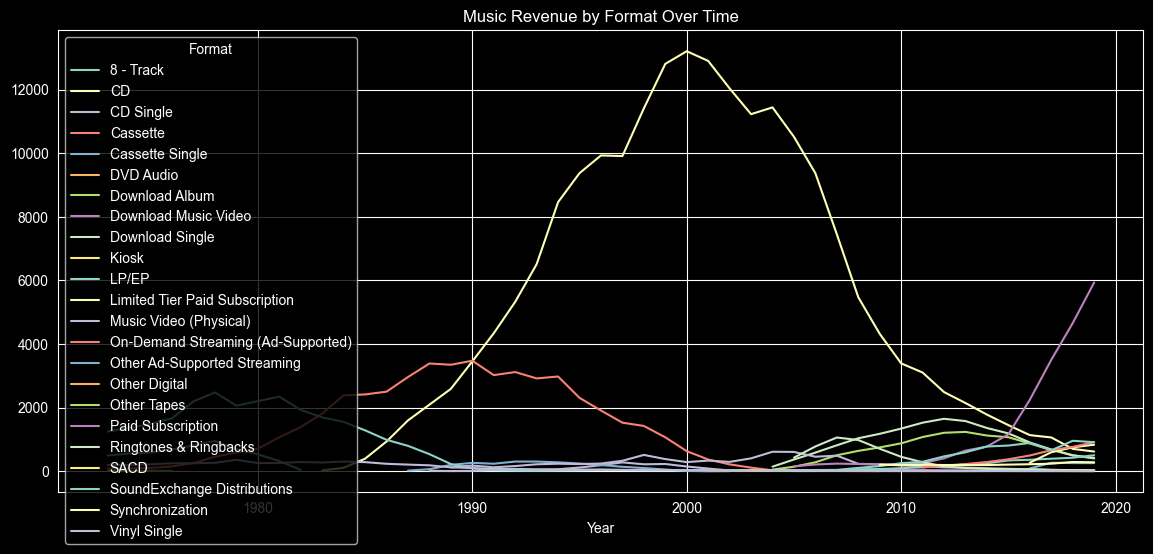

In [109]:
# --- Value over time by Format ---
pivot = df_value.pivot_table(index='Year', columns='Format', values='Value (Actual)', aggfunc='sum')
pivot.plot(figsize=(14, 6), title='Music Revenue by Format Over Time')

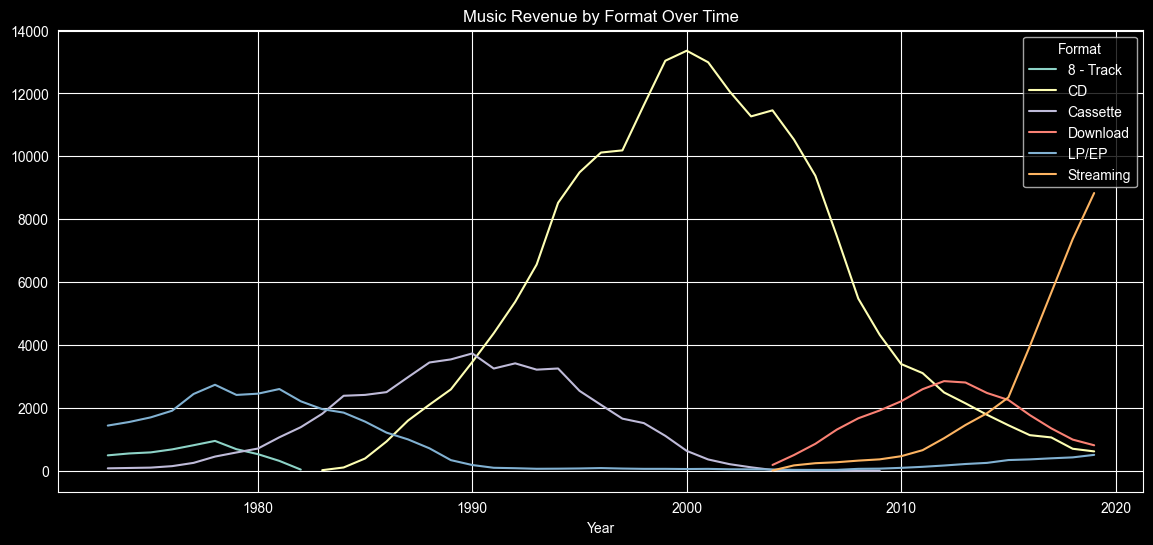

In [110]:
# --- Merge related formats ---
format_mapping = {
    '8 - Track': '8 - Track',
    'CD': 'CD',
    'CD Single': 'CD',
    'Cassette': 'Cassette',
    'Cassette Single': 'Cassette',
    'LP/EP': 'LP/EP',
    'Vinyl Single': 'LP/EP',
    'Download Album': 'Download',
    'Download Single': 'Download',
    'On-Demand Streaming (Ad-Supported)': 'Streaming',
    'Other Ad-Supported Streaming': 'Streaming',
    'Paid Subscription': 'Streaming',
    'Paid Subscriptions': 'Streaming',
    'Limited Tier Paid Subscription': 'Streaming',
    'SoundExchange Distributions': 'Streaming',
}

df_filtered = df_value[df_value['Format'].isin(format_mapping.keys())].copy()
df_filtered['Format'] = df_filtered['Format'].map(format_mapping)

# --- Pivot & plot ---
pivot = df_filtered.pivot_table(index='Year', columns='Format', values='Value (Actual)', aggfunc='sum')
pivot.plot(figsize=(14, 6), title='Music Revenue by Format Over Time')

In [111]:
df_units = df_clean[df_clean['Metric'] == 'Units']  # capital U
df_units.groupby('Format')['Value (Actual)'].sum().sort_values(ascending=False)

Format
CD                        14802.624448
Download Single           13496.701713
Cassette                   6194.300000
LP/EP                      3999.606510
Vinyl Single               2647.683034
Ringtones & Ringbacks      2124.296541
Download Album             1120.574290
8 - Track                   900.300000
Cassette Single             724.200000
Music Video (Physical)      400.836564
CD Single                   357.718686
Paid Subscriptions          351.436772
Download Music Video        136.527350
Kiosk                        24.762723
Other Tapes                   6.300000
SACD                          3.810727
DVD Audio                     2.850864
Name: Value (Actual), dtype: float64

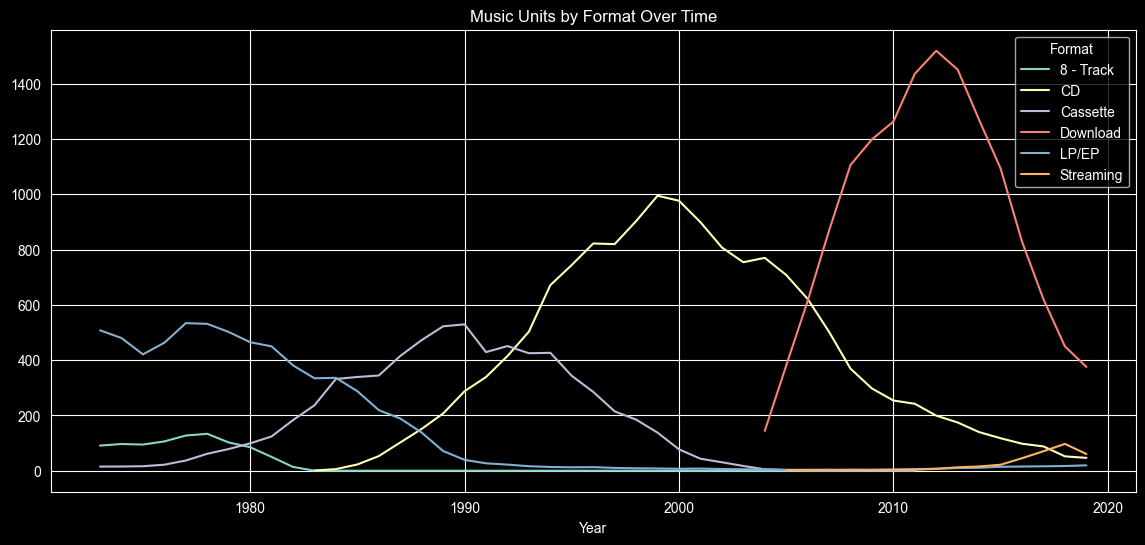

In [112]:
df_filtered_units = df_units[df_units['Format'].isin(format_mapping.keys())].copy()
df_filtered_units['Format'] = df_filtered_units['Format'].map(format_mapping)

# --- Pivot & plot ---
pivot = df_filtered_units.pivot_table(index='Year', columns='Format', values='Value (Actual)', aggfunc='sum')
pivot.plot(figsize=(14, 6), title='Music Units by Format Over Time')

In [113]:
peak_year = pivot.idxmax()
peak_value = pivot.max()

peak_df = pd.DataFrame({
    'Peak Year': peak_year,
    'Peak Value': peak_value
}).sort_values('Peak Year')

print(peak_df)

           Peak Year   Peak Value
Format                           
LP/EP           1977   534.000000
8 - Track       1978   133.600000
Cassette        1990   529.600000
CD              1999   994.800000
Download        2012  1519.473005
Streaming       2018    97.111323


In [114]:
# --- First and last year each format had non-zero revenue ---
lifecycle = {}
for fmt in pivot.columns:
    active = pivot[fmt].dropna()
    active = active[active > 0]
    if not active.empty:
        lifecycle[fmt] = {
            'First Year': active.index.min(),
            'Last Year': active.index.max(),
            'Peak Year': active.idxmax(),
            'Lifespan (years)': active.index.max() - active.index.min()
        }

lifecycle_df = pd.DataFrame(lifecycle).T.sort_values('First Year')
print(lifecycle_df)

           First Year  Last Year  Peak Year  Lifespan (years)
8 - Track        1973       1982       1978                 9
Cassette         1973       2008       1990                35
LP/EP            1973       2019       1977                46
CD               1983       2019       1999                36
Download         2004       2019       2012                15
Streaming        2005       2019       2018                14


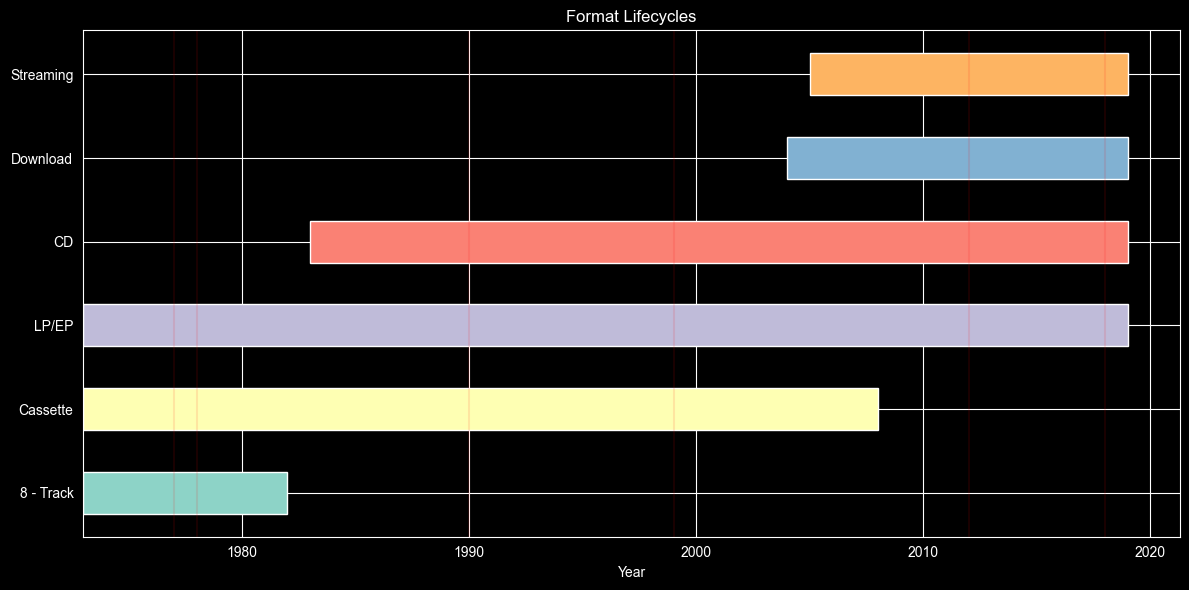

In [115]:
# --- Visualise as a Gantt-style chart ---
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(12, 6))

for i, (fmt, row) in enumerate(lifecycle_df.iterrows()):
    ax.barh(i, row['Lifespan (years)'], left=row['First Year'], height=0.5)
    ax.axvline(x=row['Peak Year'], color='red', alpha=0.1)

ax.set_yticks(range(len(lifecycle_df)))
ax.set_yticklabels(lifecycle_df.index)
ax.set_xlabel('Year')
ax.set_title('Format Lifecycles')
plt.tight_layout()
plt.show()